In [9]:
import numpy as np
import matplotlib.pyplot as plt
from os import listdir, path

In [3]:
import labmate
from labmate.acquisition_notebook import AcquisitionAnalysisManager

In [4]:
from utils.plot_style import set_plot_style 
set_plot_style()

In [7]:
# Folder
path_folder_data = r"./data/nkt/laser_fluctuation/2026-06-18_shg_injection_009/"
folder_data_files = listdir(path_folder_data)
print(folder_data_files)
# Run names
name_exp = 'laser_fluctuation_shg_injection'
# List all files in the folder
folder_data_files = listdir(path_folder_data + '/' + name_exp)
print(folder_data_files)

['laser_fluctuation_shg_injection', 'temp.json']
['2026_06_18__12_25_45__laser_fluctuation_shg_injection.h5']


In [10]:
# Choose file
name = '2026_06_18__12_25_45__laser_fluctuation_shg_injection.h5'

full_path = path.join(path_folder_data, name_exp, name)
print(full_path)

# Init acquisition analysis manager
aqm = AcquisitionAnalysisManager(full_path)
aqm.analysis_cell(filename=full_path)
print(aqm.data)

./data/nkt/laser_fluctuation/2026-06-18_shg_injection_009/laser_fluctuation_shg_injection\2026_06_18__12_25_45__laser_fluctuation_shg_injection.h5


INFO:2026_06_18__12_25_45__laser_fluctuation_shg_injection


AnalysisData (rw) (not saved): 
 {
    "acquisition_cell" (r): {
        "1": "variable of type str"
    },
    "experiment_name" (r): "variable of type str",
    "harmoniharmonik_input" (r): "shape: (15065,) (type: ndarray)",
    "harmonik_output" (r): "shape: (15065,) (type: ndarray)",
    "harmonik_temp" (r): "shape: (15065,) (type: ndarray)",
    "info" (r): {
        "acquisition_duration": "5.400e+03 (type : float64)",
        "logs": "variable of type str",
        "prints": "variable of type str"
    },
    "pm_power_mW" (r): "shape: (15065,) (type: ndarray)",
    "timestamps" (r): "shape: (15065,) (type: ndarray)",
    "useful" (r): "variable of type bool"
}


In [12]:
aqm = AcquisitionAnalysisManager(path.join(path_folder_data, name_exp))

full_path = path.join(path_folder_data, name_exp, name)
aqm.analysis_cell(filename=full_path)

data = aqm.data

timestamps = np.array(data["timestamps"])
pm_power_mW = np.array(data["pm_power_mW"])
harmonik_input = np.array(data["harmoniharmonik_input"])  # there was a typo
harmonik_output = np.array(data["harmonik_output"])
harmonik_temp = np.array(data["harmonik_temp"])

INFO:2026_06_18__12_25_45__laser_fluctuation_shg_injection


In [13]:
harmonik_input_mW = np.array(harmonik_input) * 1e3
harmonik_output_mW = np.array(harmonik_output) * 1e3

harmonik_input_rel = (
    100 * (harmonik_input_mW - np.mean(harmonik_input_mW))
    / np.mean(harmonik_input_mW)
)

harmonik_output_rel = (
    100 * (harmonik_output_mW - np.mean(harmonik_output_mW))
    / np.mean(harmonik_output_mW)
)

pm_rel = (
    100 * (pm_power_mW - np.mean(pm_power_mW))
    / np.mean(pm_power_mW)
)

harmonik_temp_rel = (
    100 * (harmonik_temp - np.mean(harmonik_temp))
    / np.mean(harmonik_temp)
)

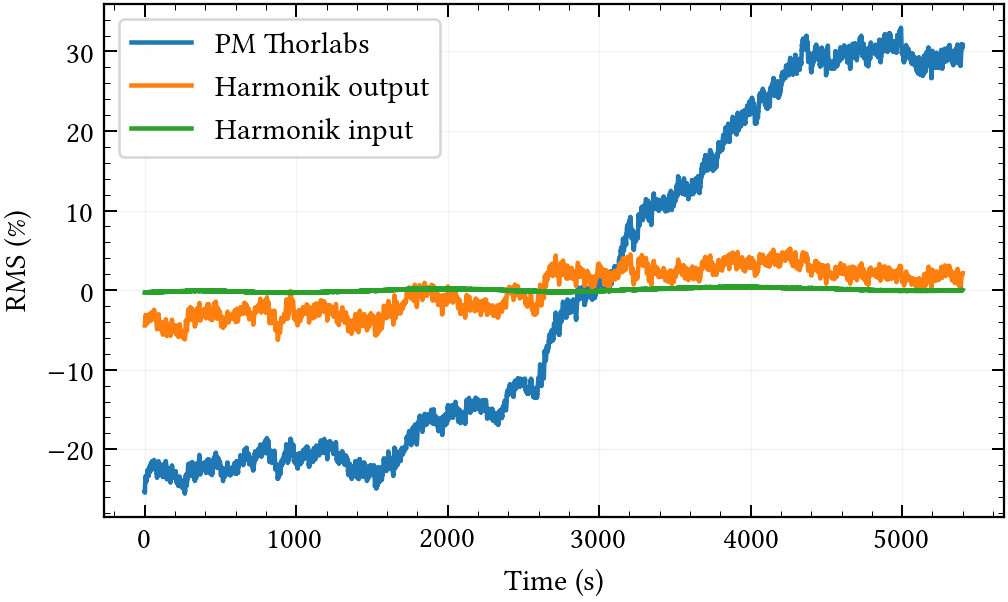

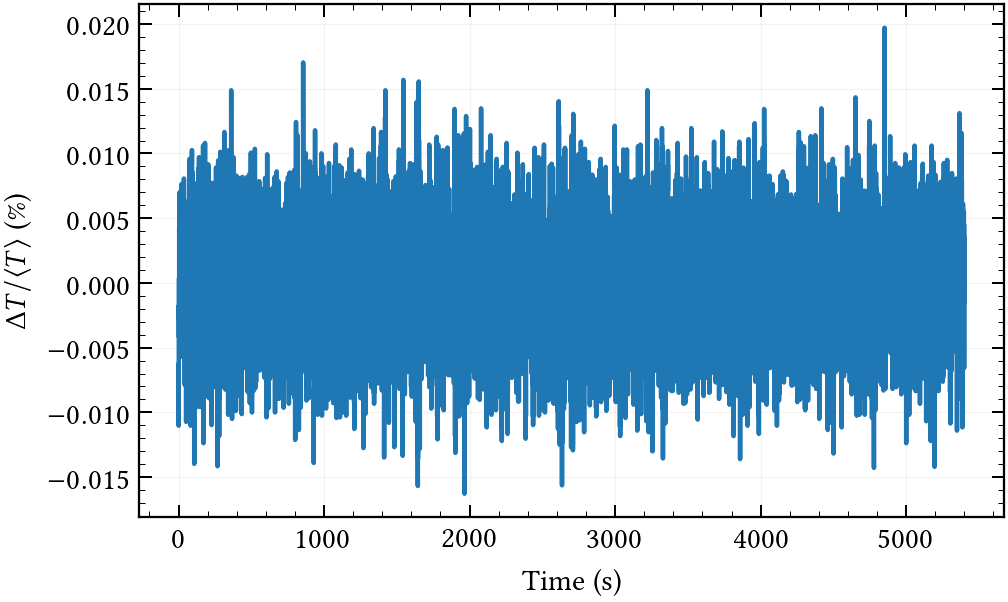

In [23]:
# Figure 1: RMS stability
fig1, ax1 = plt.subplots()

ax1.plot(timestamps, pm_rel, label="PM Thorlabs")
ax1.plot(timestamps, harmonik_output_rel, label="Harmonik output")
ax1.plot(timestamps, harmonik_input_rel, label="Harmonik input")

ax1.set_ylabel("RMS (\%)")
ax1.set_xlabel("Time (s)")
ax1.legend()
ax1.grid(True)

fig1.tight_layout()


# Figure 2: Temperature relative fluctuation
fig2, ax2 = plt.subplots()

ax2.plot(timestamps, harmonik_temp_rel)

ax2.set_ylabel(r"$\Delta T / \langle T \rangle$ (\%)")
ax2.set_xlabel("Time (s)")
ax2.grid(True)

fig2.tight_layout()

plt.show()